In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import gensim
from gensim import corpora, models
from gensim.models import CoherenceModel
import re 
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from collections import Counter

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yoga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yoga\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
transcript_df = pd.read_excel('transcript_per_video.xlsx')
transcript_df = transcript_df['Transcript']
display(transcript_df)

0       this is the first time we are in web Summit wi...
1       [Music] hello hello everybody Welcome Back to ...
2       foreign it's really my pleasure to be here tod...
3       foreign and I want to start by talking about t...
4       [Music] all right hello welcome back to anothe...
                              ...                        
1980    good afternoon and welcome to the crypto calm ...
1981    [Music] right the morning all I'm just I was g...
1982    [Music] welcome everybody welcome to day three...
1983    [Applause] good afternoon everybody this is Ma...
1984    good morning Web Summit how you guys doing thi...
Name: Transcript, Length: 1985, dtype: object

In [4]:

lemmatizer = WordNetLemmatizer()

stopwordlist = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so','than','too','very','s','t','can','will','just','don','should','now'])
def preprocess_text(text):
    #transform everything into strings
    if not isinstance(text, str):
        text = str(text)
    #remove punctuation
    #remove URLs
    text = re.sub(r'http\S+', '', text)
    #remove hashtags
    text = re.sub(r'#', '', text)
    #remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    #remove additional white spaces
    text = re.sub(r'\s+', ' ', text).strip()
    #lowercase
    text = text.lower()
    #tokenize
    tokens = text.split()
    #remove stopwords
    tokens = [token for token in tokens if token not in stopwordlist]
    #lemmatize
    lemmatized_words = [lemmatizer.lemmatize(token) for token in tokens]
    #raise NotImplementedError()
    return lemmatized_words


In [5]:

texts = transcript_df.tolist()
processed_texts = [preprocess_text(text) for text in texts]
processed_texts = [[token for token in text if token != 'u'] for text in processed_texts]
dictionary = corpora.Dictionary(processed_texts)
corpus = [dictionary.doc2bow(text) for text in processed_texts]


In [6]:
num_topics = 10
lda_model = models.LdaModel(corpus, id2word=dictionary, num_topics=num_topics)

#create document-term matrix
doc_term_matrix = [lda_model[doc] for doc in corpus]

In [7]:
def bag_of_words(tokens):
    return Counter(tokens)

#display the 20 most common words
word_list = [word for sublist in processed_texts for word in sublist]

# Count the occurrences of words
bag_of_words_counter = bag_of_words(word_list)
most_common_words = bag_of_words_counter.most_common(40) 
print(most_common_words)

[('know', 43894), ('think', 36622), ('like', 31934), ('people', 28498), ('really', 22763), ('thats', 21469), ('one', 21040), ('thing', 20907), ('right', 17931), ('going', 15999), ('get', 15943), ('company', 15307), ('actually', 14897), ('lot', 14741), ('youre', 14534), ('want', 14439), ('well', 14374), ('time', 14186), ('year', 13666), ('way', 13642), ('im', 13568), ('dont', 13436), ('need', 12175), ('go', 11948), ('there', 11945), ('see', 11818), ('kind', 11753), ('make', 11529), ('mean', 11311), ('also', 10724), ('world', 10720), ('would', 10608), ('yeah', 10599), ('much', 10013), ('work', 9951), ('say', 9637), ('something', 9522), ('data', 9510), ('technology', 8818), ('theyre', 8743)]


In [8]:
stopwordlist = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so','than','too','very','s','t','can','will','just','don','should','now'])
custom_stopwords = set(['applause', 'music', 'need', 'already', 'across', 'ahead', 'round', 'broadly', 'everything', 'honestly', 'looking', 'whenever','interesting', 'huge', 'basically', 'super', 'obviously', 'whatever', 'either', 'oh', 'th', 'ill','usually', 'especially', 'data', 'product', 'probably', 'part', 'let', 'last', 'three', 'guy', 'able', 'maybe', 'sure', 'point', 'business', 'company', 'always', 'okay', 'next', 'give', 'still', 'whats', 'little', 'today', 'important', 'bit', 'big', 'year', 'different', 'great', 'good', 'talk', 'work', 'sort', 'said', 'thank', 'day', 'new', 'back', 'two', 'world','mean', 'around', 'every', 'take', 'first', 'year', 'even', 'many', 'could', 'use', 'got', 'gonna', 'look', 'see', 'come', 'theyre', 'weve', 'go', 'uh', 'much', 'need', 'there', 'something', 'um', 'kind', 'say', 'make', 'would', 'dont', 'time', 'want', 'get', 'going', 'right', 'lot', 'also', 'yeah', 'well', 'im', 'youre', 'way', 'one','actually', 'really', 'know', 'think', 'people', 'thing', 'like', 'thats', 'u'])
customstopwords = stopwordlist.union(custom_stopwords)

def preprocess_text_new(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    tokens = text.split()
    tokens = [token for token in tokens if token not in customstopwords]
    lemmatized_words = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_words

texts = transcript_df.tolist()
processed_texts = [preprocess_text_new(text) for text in texts]
processed_texts = [[token for token in text if token not in ['u', 'thing', 'there', 'year', 'company']]
    for text in processed_texts]
dictionary = corpora.Dictionary(processed_texts)
corpus = [dictionary.doc2bow(text) for text in processed_texts]
num_topics = 30
lda_model_new = models.LdaModel(corpus, id2word=dictionary, num_topics=num_topics, alpha=50, eta=50)

#create document-term matrix
doc_term_matrix = [lda_model_new[doc] for doc in corpus]

In [9]:
word_topics = lda_model_new.print_topics()
for idx, topic in word_topics:
    print('Topic: {} \nWords: {}'.format(idx, topic))

Topic: 21 
Words: 0.000*"technology" + 0.000*"experience" + 0.000*"change" + 0.000*"start" + 0.000*"help" + 0.000*"customer" + 0.000*"team" + 0.000*"question" + 0.000*"example" + 0.000*"platform"
Topic: 14 
Words: 0.000*"technology" + 0.000*"experience" + 0.000*"platform" + 0.000*"change" + 0.000*"start" + 0.000*"content" + 0.000*"customer" + 0.000*"question" + 0.000*"medium" + 0.000*"market"
Topic: 13 
Words: 0.000*"technology" + 0.000*"question" + 0.000*"experience" + 0.000*"content" + 0.000*"team" + 0.000*"example" + 0.000*"change" + 0.000*"problem" + 0.000*"working" + 0.000*"start"
Topic: 9 
Words: 0.000*"technology" + 0.000*"question" + 0.000*"customer" + 0.000*"platform" + 0.000*"team" + 0.000*"idea" + 0.000*"start" + 0.000*"better" + 0.000*"put" + 0.000*"brand"
Topic: 24 
Words: 0.000*"technology" + 0.000*"experience" + 0.000*"market" + 0.000*"problem" + 0.000*"team" + 0.000*"change" + 0.000*"start" + 0.000*"question" + 0.000*"customer" + 0.000*"social"
Topic: 0 
Words: 0.000*"t

In [10]:
#coherence still needs to be improved
coherence_model_lda = CoherenceModel(model=lda_model, texts=processed_texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print("Coherence Score: ", coherence_lda)

Coherence Score:  0.31966654399545735


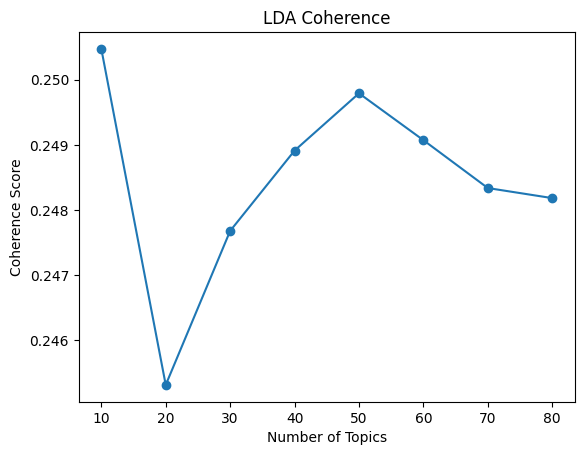

In [11]:
def compute_coherence(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        lda_model = models.LdaModel(corpus, id2word=dictionary, num_topics=num_topics)
        model_list.append(lda_model)
        doc_term_matrix = [lda_model[doc] for doc in corpus]
        
        #assess coherence and save it to a list
        coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_lda = coherence_model_lda.get_coherence()
        coherence_values.append(coherence_lda)

    return model_list, coherence_values

#apply the function to our dataset
start = 10
limit = 90
step = 10

model_list, coherence_values = compute_coherence(dictionary=dictionary, corpus=corpus, texts=processed_texts, start=start, limit=limit, step=step)

#plot coherence scores
x = range(start, limit, step)
plt.plot(x, coherence_values, marker='o')
plt.title('LDA Coherence')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.show()

In [12]:
opt_topics = range(start, limit, step)[coherence_values.index(max(coherence_values))]

#optimal number of topics
print(f"Optimal number of topics: {opt_topics}")

Optimal number of topics: 10


In [122]:
from bertopic import BERTopic

transcript_df = pd.read_excel('transcript_per_video.xlsx')
transcript_df = transcript_df['Transcript']

stopwordlist = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so','than','too','very','s','t','can','will','just','don','should','now'])
custom_stopwords = set(['anderson', 'incentivized', 'making', 'done', 'ical', 'coming', 'bring', 'example', 'welcome', 'particularly', 'specifically', 'hopefully', 'view', 'feel', 'towards', 'excited', 'happy', 'investing', 'everyone', 'hello', 'might', 'potentially', 'likely', 'impacting', 'applause', 'music', 'need', 'already', 'across', 'ahead', 'round', 'broadly', 'everything', 'honestly', 'looking', 'whenever', 'interesting', 'huge', 'basically', 'super', 'obviously', 'whatever', 'either', 'oh', 'th', 'ill','usually', 'especially', 'probably', 'part', 'let', 'last', 'three', 'guy', 'able', 'maybe', 'sure', 'point', 'always', 'okay', 'next', 'give', 'still', 'whats', 'little', 'today', 'important', 'bit', 'big', 'year', 'different', 'great', 'good', 'talk', 'work', 'sort', 'said', 'thank', 'day', 'new', 'back', 'two', 'world','mean', 'around', 'every', 'take', 'first', 'year', 'even', 'many', 'could', 'use', 'got', 'gonna', 'look', 'see', 'come', 'theyre', 'weve', 'go', 'uh', 'much', 'need', 'there', 'something', 'um', 'kind', 'say', 'make', 'would', 'dont', 'time', 'want', 'get', 'going', 'right', 'lot', 'also', 'yeah', 'well', 'im', 'youre', 'way', 'one','actually', 'really', 'know', 'think', 'people', 'thing', 'like', 'thats', 'u'])
customstopwords = stopwordlist.union(custom_stopwords)

def preprocess_text_bert(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    tokens = text.split()
    tokens = [token for token in tokens if token not in customstopwords]
    lemmatized_words = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_words

def analyze_topics(texts):

    model = BERTopic(verbose=True,embedding_model='paraphrase-MiniLM-L3-v2', min_topic_size=10)
    topics, _ = model.fit_transform(texts)
    
    freq = model.get_topic_info()
    print("Number of topics: {}".format( len(freq)))
    display(freq.head(20))
    return model,topics


transcript_df = transcript_df.apply(preprocess_text_bert)
display(transcript_df)
model,topics = analyze_topics(transcript_df[1])


0       [web, summit, stand, visible, biggest, stage, ...
1       [everybody, stage, session, another, live, str...
2       [foreign, pleasure, issue, climate, planet, su...
3       [foreign, start, talking, beatles, beatles, go...
4       [another, live, stream, stage, session, casey,...
                              ...                        
1980    [afternoon, crypto, calm, beautiful, morning, ...
1981    [morning, start, talking, went, paris, air, sh...
1982    [everybody, web, summit, modem, fashion, techn...
1983    [afternoon, everybody, matt, christian, matt, ...
1984    [morning, web, summit, guy, morning, let, hear...
Name: Transcript, Length: 1985, dtype: object

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

2024-01-07 15:22:38,356 - BERTopic - Transformed documents to Embeddings
2024-01-07 15:22:44,515 - BERTopic - Reduced dimensionality
2024-01-07 15:22:44,614 - BERTopic - Clustered reduced embeddings


Number of topics: 73


,Topic,Count,Name,Representation,Representative_Docs
0,-1,373,-1_side_pretty_enough_run,"[side, pretty, enough, run, within, put, stand...","[side, side, side]"
1,0,43,0_fund_fundraising_funding_portfolio,"[fund, fundraising, funding, portfolio, grant,...","[fund, fund, fund]"
2,1,42,1_cycle_year_long_time,"[cycle, year, long, time, month, often, speed,...","[cycle, cycle, cycle]"
3,2,40,2_comment_difference_reason_mean,"[comment, difference, reason, mean, aware, sen...","[comment, difference, reason]"
4,3,40,3_stage_audience_involved_session,"[stage, audience, involved, session, arena, he...","[stage, stage, stage]"
5,4,36,4_impact_focus_effect_damage,"[impact, focus, effect, damage, hit, focused, ...","[impact, impact, impact]"
6,5,33,5_company_corporate_chain_subsidiary,"[company, corporate, chain, subsidiary, organi...","[company, company, company]"
7,6,32,6_storage_based_movement_move,"[storage, based, movement, move, framework, ti...","[storage, storage, storage]"
8,7,31,7_tech_ai_vcs_silicon,"[tech, ai, vcs, silicon, logging, esg, , , , ]","[tech, tech, tech]"
9,8,30,8_help_panel_unit_table,"[help, panel, unit, table, sitting, line, comf...","[help, help, help]"


In [123]:
model.visualize_barchart(title="General Topics")

In [35]:
model.visualize_topics()

* add gender column for transcripts 
    * check if the title has names
    * genderize the available names
* add gender breakdown for topics 

In [87]:
import requests
import json

def identify_gender(first_name):
    base= 'https://api.genderize.io?'

    url= f'{base}name={first_name}'
    result=requests.get(url)
    
    json_str = result.text
    details= json.loads(json_str)
    gender = details.get('gender', np.NaN)

    return {'name': first_name, 'gender': gender}
# Test
res= identify_gender("Sasha")
print(res)

{'name': 'Sasha', 'gender': 'female'}


In [88]:
df = pd.read_excel('transcript_per_video.xlsx')
df_names = df['Names']

first_names = [str(x).split() if pd.notna(x) else np.NaN for x in df['Names']]

names_with_indices = []
for idx, names_list in enumerate(first_names):
    if isinstance(names_list, list) and len(names_list) == 2 and pd.notna(names_list[0]):
            names_with_indices.append({'name': names_list[0], 'index': idx})
    elif isinstance(names_list, list) and len(names_list) == 3 and pd.notna(names_list[0]):
            names_with_indices.append({'name': names_list[0], 'index': idx})
    elif isinstance(names_list, list) and len(names_list) >= 4:
        for i in range(len(names_list)):
            if i % 2 == 0 and pd.notna(names_list[i]):
                names_with_indices.append({'name': names_list[i], 'index': idx})


gender_info = [(identify_gender(entry['name']), entry['index']) for entry in names_with_indices]
gender_dict = {}

for (entry, index) in gender_info:
    if index not in gender_dict:
        gender_dict[index] = []
    gender_dict[index].append(entry['gender'])


gender_df = pd.DataFrame(gender_dict.items(), columns=['index', 'Gender_Info'])
index_df = pd.DataFrame({'index': range(len(df))})
gender_df = pd.merge(index_df, gender_df, on='index', how='left')

df = df.reset_index()
df = pd.merge(df, gender_df, on='index', how='left')
df['Gender_Info'].fillna(value='', inplace=True)
df.drop(columns=['index'], inplace=True)

df.head(40)


,Video Names,Names,Transcript,Gender_Info
0,Partner at Web Summit?,NaN,this is the first time we are in web Summit wi...,
1,Tech For Good,NaN,[Music] hello hello everybody Welcome Back to ...,
2,Innovating our way out of the carbon crisis,NaN,foreign it's really my pleasure to be here tod...,
3,What matters more: creativity or timing?,NaN,foreign and I want to start by talking about t...,
4,The Next Stage Session - Social Media,NaN,[Music] all right hello welcome back to anothe...,
5,Talking podcasts: The power of digital audio s...,NaN,foreign today we're going to talk about the ri...,
6,"Pro-tips for pitching, with Upload Ventures' R...",Rodrigo Baer,good morning um my name is Alexander Messina a...,[male]
7,Freedom Fighters: The strategy behind the knoc...,NaN,foreign [Applause] [Music] okay that's the the...,
8,Web Summit Rio 2023 | Day Three,NaN,[Music] foreign [Music] [Music] [Music] thank ...,
9,Web Summit Rio 2023 | Day Two,NaN,five thousand people are coming from different...,


In [90]:
# Assume 'Gender_Info' is a list of genders in each row
df['Gender_Combination'] = ''

for idx, row in df.iterrows():
    gender_list = row['Gender_Info']
    
    if 'male' in gender_list and 'female' in gender_list:
        df.at[idx, 'Gender_Combination'] = 'mixed'
    elif 'male' in gender_list:
        df.at[idx, 'Gender_Combination'] = 'male'
    elif 'female' in gender_list:
        df.at[idx, 'Gender_Combination'] = 'female'


df.head(40)

,Video Names,Names,Transcript,Gender_Info,Gender_Combination
0,Partner at Web Summit?,NaN,this is the first time we are in web Summit wi...,,
1,Tech For Good,NaN,[Music] hello hello everybody Welcome Back to ...,,
2,Innovating our way out of the carbon crisis,NaN,foreign it's really my pleasure to be here tod...,,
3,What matters more: creativity or timing?,NaN,foreign and I want to start by talking about t...,,
4,The Next Stage Session - Social Media,NaN,[Music] all right hello welcome back to anothe...,,
5,Talking podcasts: The power of digital audio s...,NaN,foreign today we're going to talk about the ri...,,
6,"Pro-tips for pitching, with Upload Ventures' R...",Rodrigo Baer,good morning um my name is Alexander Messina a...,[male],male
7,Freedom Fighters: The strategy behind the knoc...,NaN,foreign [Applause] [Music] okay that's the the...,,
8,Web Summit Rio 2023 | Day Three,NaN,[Music] foreign [Music] [Music] [Music] thank ...,,
9,Web Summit Rio 2023 | Day Two,NaN,five thousand people are coming from different...,,


In [95]:
from bertopic import BERTopic

stopwordlist = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so','than','too','very','s','t','can','will','just','don','should','now'])
custom_stopwords = set(['anderson', 'incentivized', 'making', 'done', 'ical', 'coming', 'bring', 'example', 'welcome', 'particularly', 'specifically', 'hopefully', 'view', 'feel', 'towards', 'excited', 'happy', 'investing', 'everyone', 'hello', 'might', 'potentially', 'likely', 'impacting', 'applause', 'music', 'need', 'already', 'across', 'ahead', 'round', 'broadly', 'everything', 'honestly', 'looking', 'whenever', 'interesting', 'huge', 'basically', 'super', 'obviously', 'whatever', 'either', 'oh', 'th', 'ill','usually', 'especially', 'probably', 'part', 'let', 'last', 'three', 'guy', 'able', 'maybe', 'sure', 'point', 'always', 'okay', 'next', 'give', 'still', 'whats', 'little', 'today', 'important', 'bit', 'big', 'year', 'different', 'great', 'good', 'talk', 'work', 'sort', 'said', 'thank', 'day', 'new', 'back', 'two', 'world','mean', 'around', 'every', 'take', 'first', 'year', 'even', 'many', 'could', 'use', 'got', 'gonna', 'look', 'see', 'come', 'theyre', 'weve', 'go', 'uh', 'much', 'need', 'there', 'something', 'um', 'kind', 'say', 'make', 'would', 'dont', 'time', 'want', 'get', 'going', 'right', 'lot', 'also', 'yeah', 'well', 'im', 'youre', 'way', 'one','actually', 'really', 'know', 'think', 'people', 'thing', 'like', 'thats', 'u'])
customstopwords = stopwordlist.union(custom_stopwords)
lemmatizer = WordNetLemmatizer()

def preprocess_text_bert(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    tokens = text.split()
    tokens = [token for token in tokens if token not in customstopwords]
    lemmatized_words = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_words

def analyze_topics(texts):

    model = BERTopic(verbose=True,embedding_model='paraphrase-MiniLM-L3-v2', min_topic_size=10)
    topics, _ = model.fit_transform(texts)
    
    freq = model.get_topic_info()
    print("Number of topics: {}".format( len(freq)))
    display(freq.head(20))
    return model,topics

In [115]:
male_df = df[df['Gender_Combination'] == 'male']
tr_male_df = male_df['Transcript']
tr_male_df = tr_male_df.apply(preprocess_text_bert)
tr_male_df.reset_index(drop=True, inplace=True)
display(tr_male_df)
model,topics = analyze_topics(tr_male_df[1])

0     [morning, name, alexander, messina, present, z...
1     [foreign, know, famous, footballer, gift, audi...
2     [foreign, major, obstacle, face, society, some...
3     [foreign, hanging, session, night, session, be...
4     [foreign, yes, art, let, start, art, art, ques...
5     [foreign, word, there, final, act, moment, int...
6     [foreign, opportunity, share, thought, share, ...
7     [achieve, change, idea, lose, room, force, ent...
8     [achieve, change, idea, lose, room, force, ent...
9     [idea, member, human, family, must, mind, free...
10    [idea, member, human, family, must, mind, free...
11    [carlos, garcia, galan, head, european, servic...
12    [truly, believe, revolutionary, game, changing...
13    [present, host, daily, political, show, youtub...
14    [course, hindsight, problem, name, sridhar, ra...
15    [stage, offer, nothing, word, senior, governme...
16    [collision, toronto, truly, honor, set, prime,...
17    [morning, everybody, growth, summit, web, 

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

2024-01-07 15:19:38,956 - BERTopic - Transformed documents to Embeddings
2024-01-07 15:19:42,617 - BERTopic - Reduced dimensionality
2024-01-07 15:19:42,674 - BERTopic - Clustered reduced embeddings


Number of topics: 45


,Topic,Count,Name,Representation,Representative_Docs
0,-1,246,-1_value_nft_specific_reach,"[value, nft, specific, reach, lose, best, oppo...","[value, value, value]"
1,0,58,0_sport_stadium_goal_score,"[sport, stadium, goal, score, kick, active, ba...","[sport, sport, sport]"
2,1,45,1_meaning_term_related_understand,"[meaning, term, related, understand, recognize...","[meaning, related, term]"
3,2,43,2_relationship_share_interaction_embrace,"[relationship, share, interaction, embrace, co...","[relationship, relationship, relationship]"
4,3,37,3_company_entrepreneur_business_club,"[company, entrepreneur, business, club, experi...","[company, company, company]"
5,4,37,4_fan_vibe__,"[fan, vibe, , , , , , , , ]","[fan, fan, fan]"
6,5,36,5_moment_fun_long_wait,"[moment, fun, long, wait, minute, fast, clap, ...","[moment, fun, moment]"
7,6,35,6_later_grew_recently_ago,"[later, grew, recently, ago, life, bringing, f...","[later, later, later]"
8,7,32,7_cup_there_walk_morning,"[cup, there, walk, morning, middle, trophy, to...","[there, there, cup]"
9,8,31,8_game_played_player_play,"[game, played, player, play, playing, poker, s...","[game, game, game]"


In [116]:
model.visualize_barchart(title="Men Topics")

In [117]:
female_df = df[df['Gender_Combination'] == 'female']
tr_female_df = female_df['Transcript']
tr_female_df = tr_female_df.apply(preprocess_text_bert)
tr_female_df.reset_index(drop=True, inplace=True)
display(tr_female_df)
model,topics = analyze_topics(tr_female_df[1])

0     [foreign, hi, everybody, naomi, hi, thanks, jo...
1     [foreign, old, iranianamerican, climate, activ...
2     [foreign, war, ask, help, ukraine, introduce, ...
3     [six, month, fight, lost, fight, fight, heart,...
4     [six, month, fight, lost, fight, fight, fear, ...
5     [there, complicity, among, industry, allow, po...
6     [long, everybody, get, rich, oil, gas, never, ...
7     [sorry, shuffling, furniture, slightly, closer...
8     [introduced, man, share, newest, trend, low, c...
9     [social, medium, marketing, mac, job, four, mo...
10    [executive, cambridge, analytica, gone, prison...
11    [stay, curious, ask, question, never, lose, ab...
12    [afternoon, health, place, science, technology...
13    [hi, guy, lunch, hope, eating, food, ate, food...
14    [hi, fanda, problem, ive, seo, trend, skill, l...
15    [afternoon, everybody, field, upstage, startup...
16    [played, sport, jayne, gideon, sir, full, lunc...
17    [gaming, year, ago, crazy, another, guy, l

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

2024-01-07 15:20:02,231 - BERTopic - Transformed documents to Embeddings
2024-01-07 15:20:04,881 - BERTopic - Reduced dimensionality
2024-01-07 15:20:04,908 - BERTopic - Clustered reduced embeddings


Number of topics: 24


,Topic,Count,Name,Representation,Representative_Docs
0,-1,138,-1_together_resource_woman_social,"[together, resource, woman, social, percent, f...","[together, together, together]"
1,0,47,0_realized_step_difference_fact,"[realized, step, difference, fact, learned, se...","[realized, realized, realized]"
2,1,34,1_climate_green_water_warming,"[climate, green, water, warming, sustainable, ...","[climate, climate, climate]"
3,2,32,2_term_mention_general_voice,"[term, mention, general, voice, word, language...","[term, term, general]"
4,3,31,3_future_ultimately_policy_currently,"[future, ultimately, policy, currently, farsi,...","[future, future, future]"
5,4,31,4_nation_iran_country_united,"[nation, iran, country, united, egypt, native,...","[nation, nation, nation]"
6,5,30,5_change_movement_action_strike,"[change, movement, action, strike, move, strik...","[change, change, change]"
7,6,30,6_tech_company_working_pay,"[tech, company, working, pay, organization, ma...","[company, company, tech]"
8,7,28,7_climate_drought_temperature_solar,"[climate, drought, temperature, solar, , , , ,...","[climate, climate, climate]"
9,8,26,8_cop_upon_street_stand,"[cop, upon, street, stand, intersectional, get...","[cop, cop, cop]"


In [118]:
model.visualize_barchart(title="Women Topics")

In [119]:
mixed_df = df[df['Gender_Combination'] == 'mixed']
tr_mixed_df = mixed_df['Transcript']
tr_mixed_df = tr_mixed_df.apply(preprocess_text_bert)
tr_mixed_df.reset_index(drop=True, inplace=True)
display(tr_mixed_df)
model,topics = analyze_topics(tr_female_df[1])

0    [foreign, morning, final, web, summit, hows, f...
1    [foreign, pinnacle, motorsport, fastest, labor...
2    [thanks, ask, question, mind, group, guy, foll...
3    [please, stage, ceo, cofounder, collision, web...
Name: Transcript, dtype: object

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

2024-01-07 15:20:50,123 - BERTopic - Transformed documents to Embeddings
2024-01-07 15:20:52,796 - BERTopic - Reduced dimensionality
2024-01-07 15:20:52,824 - BERTopic - Clustered reduced embeddings


Number of topics: 23


,Topic,Count,Name,Representation,Representative_Docs
0,-1,139,-1_resource_woman_percent_social,"[resource, woman, percent, social, facing, bru...","[resource, resource, resource]"
1,0,44,0_realized_step_difference_fact,"[realized, step, difference, fact, sense, lear...","[realized, realized, realized]"
2,1,34,1_climate_green_water_warming,"[climate, green, water, warming, sustainable, ...","[climate, climate, climate]"
3,2,32,2_future_ultimately_currently_policy,"[future, ultimately, currently, policy, farsi,...","[future, future, future]"
4,3,32,3_term_mention_general_voice,"[term, mention, general, voice, word, language...","[mention, mention, term]"
5,4,32,4_cop_getting_upon_street,"[cop, getting, upon, street, stand, access, in...","[cop, cop, cop]"
6,5,30,5_change_movement_action_strike,"[change, movement, action, strike, move, strik...","[change, change, change]"
7,6,28,6_climate_drought_temperature_solar,"[climate, drought, temperature, solar, , , , ,...","[climate, climate, climate]"
8,7,27,7_company_working_pay_organization,"[company, working, pay, organization, made, he...","[company, company, company]"
9,8,25,8_nation_iran_country_egypt,"[nation, iran, country, egypt, native, iranian...","[nation, nation, nation]"


In [120]:
model.visualize_barchart(title="Men and Women Topics")